In [1]:
!nvidia-smi

Fri Oct  9 05:02:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:

from numba import cuda

device = cuda.get_current_device()

print(f"Device Name: {device.name}")
print(f"Compute Capability: {device.compute_capability}")
print(f"Multiprocessor Count (SMs): {getattr(device, 'MULTIPROCESSOR_COUNT', 'N/A')}")
print(f"Max Threads Per Block: {device.MAX_THREADS_PER_BLOCK}")
print(f"Max Block Dimensions: {device.MAX_BLOCK_DIM_X}, {device.MAX_BLOCK_DIM_Y}, {device.MAX_BLOCK_DIM_Z}")
print(f"Warp Size: {device.WARP_SIZE}")


Device Name: Tesla T4
Compute Capability: ComputeCapability(major=7, minor=5)
Multiprocessor Count (SMs): 40
Max Threads Per Block: 1024
Max Block Dimensions: 1024, 1024, 64
Warp Size: 32


In [3]:

import numpy as np
import time
from numba import cuda

# CPU implementation
def double_cpu_pure(arr):
    out = np.empty_like(arr)
    for i in range(len(arr)):
        out[i] = arr[i] * 2.0
    return out

# GPU implementation
@cuda.jit
def double_gpu_kernel(d_in, d_out):
    idx = cuda.grid(1)
    if idx < d_in.shape[0]:
        d_out[idx] = d_in[idx] * 2.0


In [4]:

def benchmark_run(N, student_id_seed=230103120):
    np.random.seed(student_id_seed)
    h_in = np.random.rand(N).astype(np.float32)

    # CPU measurement
    if N <= 1_000_000:
        t0 = time.perf_counter()
        cpu_result = double_cpu_pure(h_in)
        cpu_time_ms = (time.perf_counter() - t0) * 1000
    else:
        cpu_time_ms = float("nan")

    # GPU configuration
    threads_per_block = 256
    blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

    # GPU warmup
    d_warmup = cuda.to_device(np.ones(10, dtype=np.float32))
    double_gpu_kernel[1, 32](d_warmup, d_warmup)
    cuda.synchronize()

    # GPU total time
    t0 = time.perf_counter()
    d_in = cuda.to_device(h_in)
    d_out = cuda.device_array_like(d_in)

    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    h_out = d_out.copy_to_host()
    cuda.synchronize()

    gpu_total_ms = (time.perf_counter() - t0) * 1000

    # GPU kernel only
    t0 = time.perf_counter()
    double_gpu_kernel[blocks_per_grid, threads_per_block](d_in, d_out)
    cuda.synchronize()

    gpu_compute_ms = (time.perf_counter() - t0) * 1000

    return cpu_time_ms, gpu_total_ms, gpu_compute_ms


In [5]:

sizes = [100, 1000, 10000, 100000, 1000000, 5000000, 10000000]

results = []

print(f"{'N':<12} {'CPU (ms)':<15} {'GPU Total (ms)':<18} {'GPU Kernel (ms)':<18} {'Winner'}")

for N in sizes:
    cpu, gpu_total, gpu_kernel = benchmark_run(N)

    if np.isnan(cpu):
        winner = "N/A"
    else:
        winner = "GPU" if gpu_total < cpu else "CPU"

    results.append((N, cpu, gpu_total, gpu_kernel, winner))

    print(f"{N:<12} {cpu:<15.4f} {gpu_total:<18.4f} {gpu_kernel:<18.4f} {winner}")


N            CPU (ms)        GPU Total (ms)     GPU Kernel (ms)    Winner


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 1 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 4 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))
/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 40 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


100          0.0593          1.2015             0.0953             CPU
1000         0.5451          0.7126             0.0811             CPU
10000        5.0002          0.6874             0.0966             GPU
100000       48.9869         0.9598             0.1110             GPU
1000000      492.3038        5.7746             0.1648             GPU
5000000      nan             15.2494            0.2951             N/A
10000000     nan             28.1883            0.4978             N/A


In [6]:

@cuda.jit
def defective_kernel(d_arr):
    idx = cuda.grid(1)
    d_arr[idx] = 999.0

N = 1000
h_arr = np.zeros(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = 4

print("Launching defective kernel...")
defective_kernel[blocks_per_grid, threads_per_block](d_arr)
cuda.synchronize()

print("Execution finished.")
h_result = d_arr.copy_to_host()
print(f"Elements processed: {len(h_result)}")
print(f"Last element: {h_result[-1]}")


Launching defective kernel...
Execution finished.
Elements processed: 1000
Last element: 999.0


In [7]:

from numba import cuda
import numpy as np

@cuda.jit
def inspect_threads_kernel(log_block, log_thread, log_global, log_active, N):
    t_idx = cuda.threadIdx.x
    b_idx = cuda.blockIdx.x
    g_idx = cuda.grid(1)

    if g_idx < log_block.shape[0]:
        log_block[g_idx] = b_idx
        log_thread[g_idx] = t_idx
        log_global[g_idx] = g_idx
        log_active[g_idx] = 1 if g_idx < N else 0

N = 37
threads_per_block = 8
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

total_threads = blocks_per_grid * threads_per_block

log_b = cuda.device_array(total_threads, dtype=np.int32)
log_t = cuda.device_array(total_threads, dtype=np.int32)
log_g = cuda.device_array(total_threads, dtype=np.int32)
log_a = cuda.device_array(total_threads, dtype=np.int32)

inspect_threads_kernel[blocks_per_grid, threads_per_block](
    log_b, log_t, log_g, log_a, N
)
cuda.synchronize()

# Copy data back to CPU
log_b = log_b.copy_to_host()
log_t = log_t.copy_to_host()
log_g = log_g.copy_to_host()
log_a = log_a.copy_to_host()

print(f"{'Global ID':<10} | {'Block ID':<10} | {'Thread ID':<10} | {'Status'}")
print("-" * 55)

for i in range(32, 40):
    status = "ACTIVE" if log_a[i] == 1 else "IDLE (GUARDED)"
    print(f"{log_g[i]:<10} | {log_b[i]:<10} | {log_t[i]:<10} | {status}")

print("\nTotal Blocks:", blocks_per_grid)
print("Total Threads:", total_threads)
print("Active Threads:", np.sum(log_a))
print("Idle Threads:", total_threads - np.sum(log_a))


Global ID  | Block ID   | Thread ID  | Status
-------------------------------------------------------
32         | 4          | 0          | ACTIVE
33         | 4          | 1          | ACTIVE
34         | 4          | 2          | ACTIVE
35         | 4          | 3          | ACTIVE
36         | 4          | 4          | ACTIVE
37         | 4          | 5          | IDLE (GUARDED)
38         | 4          | 6          | IDLE (GUARDED)
39         | 4          | 7          | IDLE (GUARDED)

Total Blocks: 5
Total Threads: 40
Active Threads: 37
Idle Threads: 3


/usr/local/lib/python3.13/dist-packages/numba_cuda/numba/cuda/dispatcher.py:716: NumbaPerformanceWarning: Grid size 5 will likely result in GPU under-utilization due to low occupancy.
  warn(errors.NumbaPerformanceWarning(msg))


In [8]:

from numba import cuda
import numpy as np
import time

# Incorrect summation: Race Condition
@cuda.jit
def naive_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        d_total[0] += d_arr[idx]

# Correct summation: Atomic Operation
@cuda.jit
def atomic_sum_kernel(d_arr, d_total):
    idx = cuda.grid(1)
    if idx < d_arr.shape[0]:
        cuda.atomic.add(d_total, 0, d_arr[idx])


In [9]:

N = 50000

h_arr = np.ones(N, dtype=np.float32)
d_arr = cuda.to_device(h_arr)

threads_per_block = 256
blocks_per_grid = (N + threads_per_block - 1) // threads_per_block

print("Trial | Target Sum | Naive Output | Lost Updates")
print("-" * 60)

for trial in range(1, 6):
    d_total = cuda.to_device(np.zeros(1, dtype=np.float32))

    naive_sum_kernel[blocks_per_grid, threads_per_block](d_arr, d_total)
    cuda.synchronize()

    result = d_total.copy_to_host()[0]
    deviation = N - result

    print(f"{trial:<5} | {N:<10} | {result:<12.1f} | {deviation:.1f}")


Trial | Target Sum | Naive Output | Lost Updates
------------------------------------------------------------
1     | 50000      | 2.0          | 49998.0
2     | 50000      | 2.0          | 49998.0
3     | 50000      | 2.0          | 49998.0
4     | 50000      | 2.0          | 49998.0
5     | 50000      | 2.0          | 49998.0


In [10]:

# Warm up both kernels
warmup_total = cuda.to_device(np.zeros(1, dtype=np.float32))
naive_sum_kernel[blocks_per_grid, threads_per_block](d_arr, warmup_total)
cuda.synchronize()

warmup_total = cuda.to_device(np.zeros(1, dtype=np.float32))
atomic_sum_kernel[blocks_per_grid, threads_per_block](d_arr, warmup_total)
cuda.synchronize()

# Naive sum timing
d_total_naive = cuda.to_device(np.zeros(1, dtype=np.float32))

t0 = time.perf_counter()
naive_sum_kernel[blocks_per_grid, threads_per_block](d_arr, d_total_naive)
cuda.synchronize()
naive_time = (time.perf_counter() - t0) * 1000

# Atomic sum timing
d_total_atomic = cuda.to_device(np.zeros(1, dtype=np.float32))

t0 = time.perf_counter()
atomic_sum_kernel[blocks_per_grid, threads_per_block](d_arr, d_total_atomic)
cuda.synchronize()
atomic_time = (time.perf_counter() - t0) * 1000

atomic_result = d_total_atomic.copy_to_host()[0]

print("Atomic Sum Output:", atomic_result)
print("Correct:", atomic_result == 50000.0)
print(f"Naive Kernel Time: {naive_time:.4f} ms")
print(f"Atomic Kernel Time: {atomic_time:.4f} ms")


Atomic Sum Output: 50000.0
Correct: True
Naive Kernel Time: 0.4055 ms
Atomic Kernel Time: 0.3670 ms


Grid Blocks X: 64
Grid Blocks Y: 64
Total Blocks: 4096
Matrix Shape: (1024, 1024)
Center Pixel: 1.0
Corner Pixel: 0.0


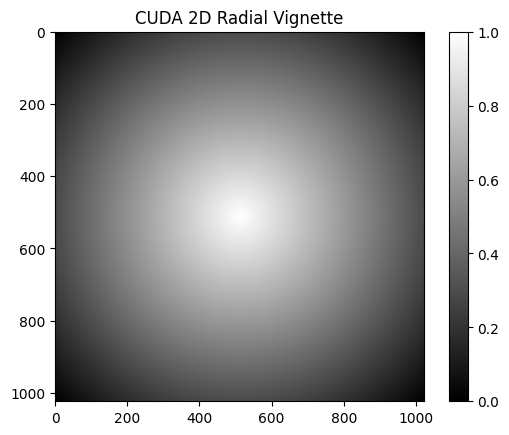

In [11]:

import numpy as np
import math
from numba import cuda
import matplotlib.pyplot as plt

@cuda.jit
def radial_vignette_2d(d_canvas, width, height, center_x, center_y):
    x, y = cuda.grid(2)

    if x < width and y < height:
        dx = float(x - center_x)
        dy = float(y - center_y)

        dist = math.sqrt(dx * dx + dy * dy)
        max_dist = math.sqrt(float(center_x**2 + center_y**2))

        intensity = 1.0 - (dist / max_dist)

        if intensity < 0.0:
            intensity = 0.0

        d_canvas[y, x] = intensity

# Matrix dimensions
WIDTH, HEIGHT = 1024, 1024

canvas = np.zeros((HEIGHT, WIDTH), dtype=np.float32)
d_canvas = cuda.to_device(canvas)

# CUDA 2D configuration
threads_2d = (16, 16)

blocks_2d = (
    (WIDTH + threads_2d[0] - 1) // threads_2d[0],
    (HEIGHT + threads_2d[1] - 1) // threads_2d[1]
)

# Execute GPU kernel
radial_vignette_2d[blocks_2d, threads_2d](
    d_canvas, WIDTH, HEIGHT, WIDTH // 2, HEIGHT // 2
)

cuda.synchronize()

result_canvas = d_canvas.copy_to_host()

# Print results
print("Grid Blocks X:", blocks_2d[0])
print("Grid Blocks Y:", blocks_2d[1])
print("Total Blocks:", blocks_2d[0] * blocks_2d[1])

print("Matrix Shape:", result_canvas.shape)
print("Center Pixel:", result_canvas[512, 512])
print("Corner Pixel:", result_canvas[0, 0])

# Show image
plt.imshow(result_canvas, cmap="gray")
plt.title("CUDA 2D Radial Vignette")
plt.colorbar()
plt.show()


In [13]:

import hashlib
from numba import cuda

def generate_lab_checksum(student_id_str, d_canvas, exp_table_crossover):
    h = hashlib.sha256()

    h.update(student_id_str.strip().encode('utf-8'))
    h.update(cuda.get_current_device().name.encode('utf-8'))
    h.update(d_canvas.copy_to_host()[:10, :10].tobytes())
    h.update(str(exp_table_crossover).encode('utf-8'))

    digest = h.hexdigest()[:16].upper()

    print("=" * 60)
    print(f"OFFICIAL VERIFICATION CHECKSUM TOKEN: {digest}")
    print("=" * 60)

    return digest

STUDENT_ID = "230103120"
CROSSOVER_N = 10000

generate_lab_checksum(STUDENT_ID, d_canvas, CROSSOVER_N)


OFFICIAL VERIFICATION CHECKSUM TOKEN: 2941A35DB66A341E


'2941A35DB66A341E'